# Epoch Timing Analysis

Per-epoch training time statistics across models.


In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, mannwhitneyu
from sklearn.metrics import (confusion_matrix, roc_curve, precision_recall_curve, auc, 
                              brier_score_loss, accuracy_score, f1_score, recall_score, 
                              precision_score, cohen_kappa_score)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Plotting setup
sns.set_style('whitegrid')
sns.set_context('paper', font_scale=1.2)
plt.rcParams.update({
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial']
})

# Paths
OUTPUT_BASE = 'folds/folds/output'
FIG_DIR = 'q1_publication_results'
os.makedirs(FIG_DIR, exist_ok=True)
for subdir in ['figures', 'tables', 'supplementary']:
    os.makedirs(os.path.join(FIG_DIR, subdir), exist_ok=True)

print("✓ Setup complete!")

✓ Setup complete!


In [20]:
# Load epoch timing data
epoch_times_all = []
for fold_dir in sorted(glob.glob(os.path.join(OUTPUT_BASE, 'FOLD_*'))):
    for run_dir in sorted(glob.glob(os.path.join(fold_dir, 'run_*'))):
        epoch_file = os.path.join(run_dir, 'final/epoch_times_final.csv')
        if os.path.exists(epoch_file):
            try:
                df = pd.read_csv(epoch_file)
                df['fold'] = os.path.basename(fold_dir)
                df['run'] = os.path.basename(run_dir)
                epoch_times_all.append(df)
            except:
                pass

if epoch_times_all:
    epoch_df = pd.concat(epoch_times_all, ignore_index=True)
    print(f"Total epoch records: {len(epoch_df)}")
    print(f"Unique runs: {epoch_df.groupby(['fold', 'run']).ngroups}")
    epoch_df.head()
else:
    print("No epoch timing data found")

Total epoch records: 2211
Unique runs: 50


In [21]:
if epoch_times_all:
    # Calculate per-epoch statistics
    if 'epoch' in epoch_df.columns and 'epoch_time' in epoch_df.columns:
        per_epoch_stats = epoch_df.groupby('epoch')['epoch_time'].agg(['mean', 'std', 'min', 'max', 'count'])
        
        print("\n" + "="*80)
        print("PER-EPOCH COMPLETION TIME STATISTICS (seconds)")
        print("="*80)
        print(per_epoch_stats.to_string())
        print("="*80)
        
        # Overall statistics
        overall_stats = {
            'Mean Epoch Time (sec)': f"{epoch_df['epoch_time'].mean():.2f}",
            'Std Epoch Time (sec)': f"{epoch_df['epoch_time'].std():.2f}",
            'Min Epoch Time (sec)': f"{epoch_df['epoch_time'].min():.2f}",
            'Max Epoch Time (sec)': f"{epoch_df['epoch_time'].max():.2f}",
            'Median Epoch Time (sec)': f"{epoch_df['epoch_time'].median():.2f}",
            'Total Epochs Trained': len(epoch_df)
        }
        
        print("\nOVERALL EPOCH TIME SUMMARY:")
        for key, val in overall_stats.items():
            print(f"  {key}: {val}")
        
        # Save statistics
        per_epoch_stats.to_csv(os.path.join(FIG_DIR, 'tables/per_epoch_time_stats.csv'))
        pd.DataFrame([overall_stats]).to_csv(os.path.join(FIG_DIR, 'tables/overall_epoch_time_stats.csv'), index=False)
        
        print("\n✓ Epoch timing statistics saved!")


PER-EPOCH COMPLETION TIME STATISTICS (seconds)
            mean       std        min        max  count
epoch                                                  
1.0    17.106919  1.924760  14.695351  24.631274     50
2.0    17.100696  1.900211  14.345001  24.528282     50
3.0    17.088494  1.924133  14.497633  24.417776     50
4.0    17.133768  1.966911  14.628783  25.186333     50
5.0    17.128883  1.964576  14.630516  25.093064     50
6.0    20.621193  3.295112  16.263691  30.852052     50
7.0    20.578186  3.377736  16.387037  30.623207     50
8.0    20.611898  3.339997  16.353752  30.607569     50
9.0    20.691146  3.416085  16.294608  31.408213     48
10.0   20.577145  3.261368  16.193536  30.619678     47
11.0   20.568021  3.390237  16.209661  30.979895     45
12.0   20.711749  3.443865  16.104524  31.284691     43
13.0   20.784758  3.461142  16.135040  31.726502     42
14.0   20.689792  3.484832  16.163901  30.929594     42
15.0   20.680412  3.376658  16.511718  30.157396     40


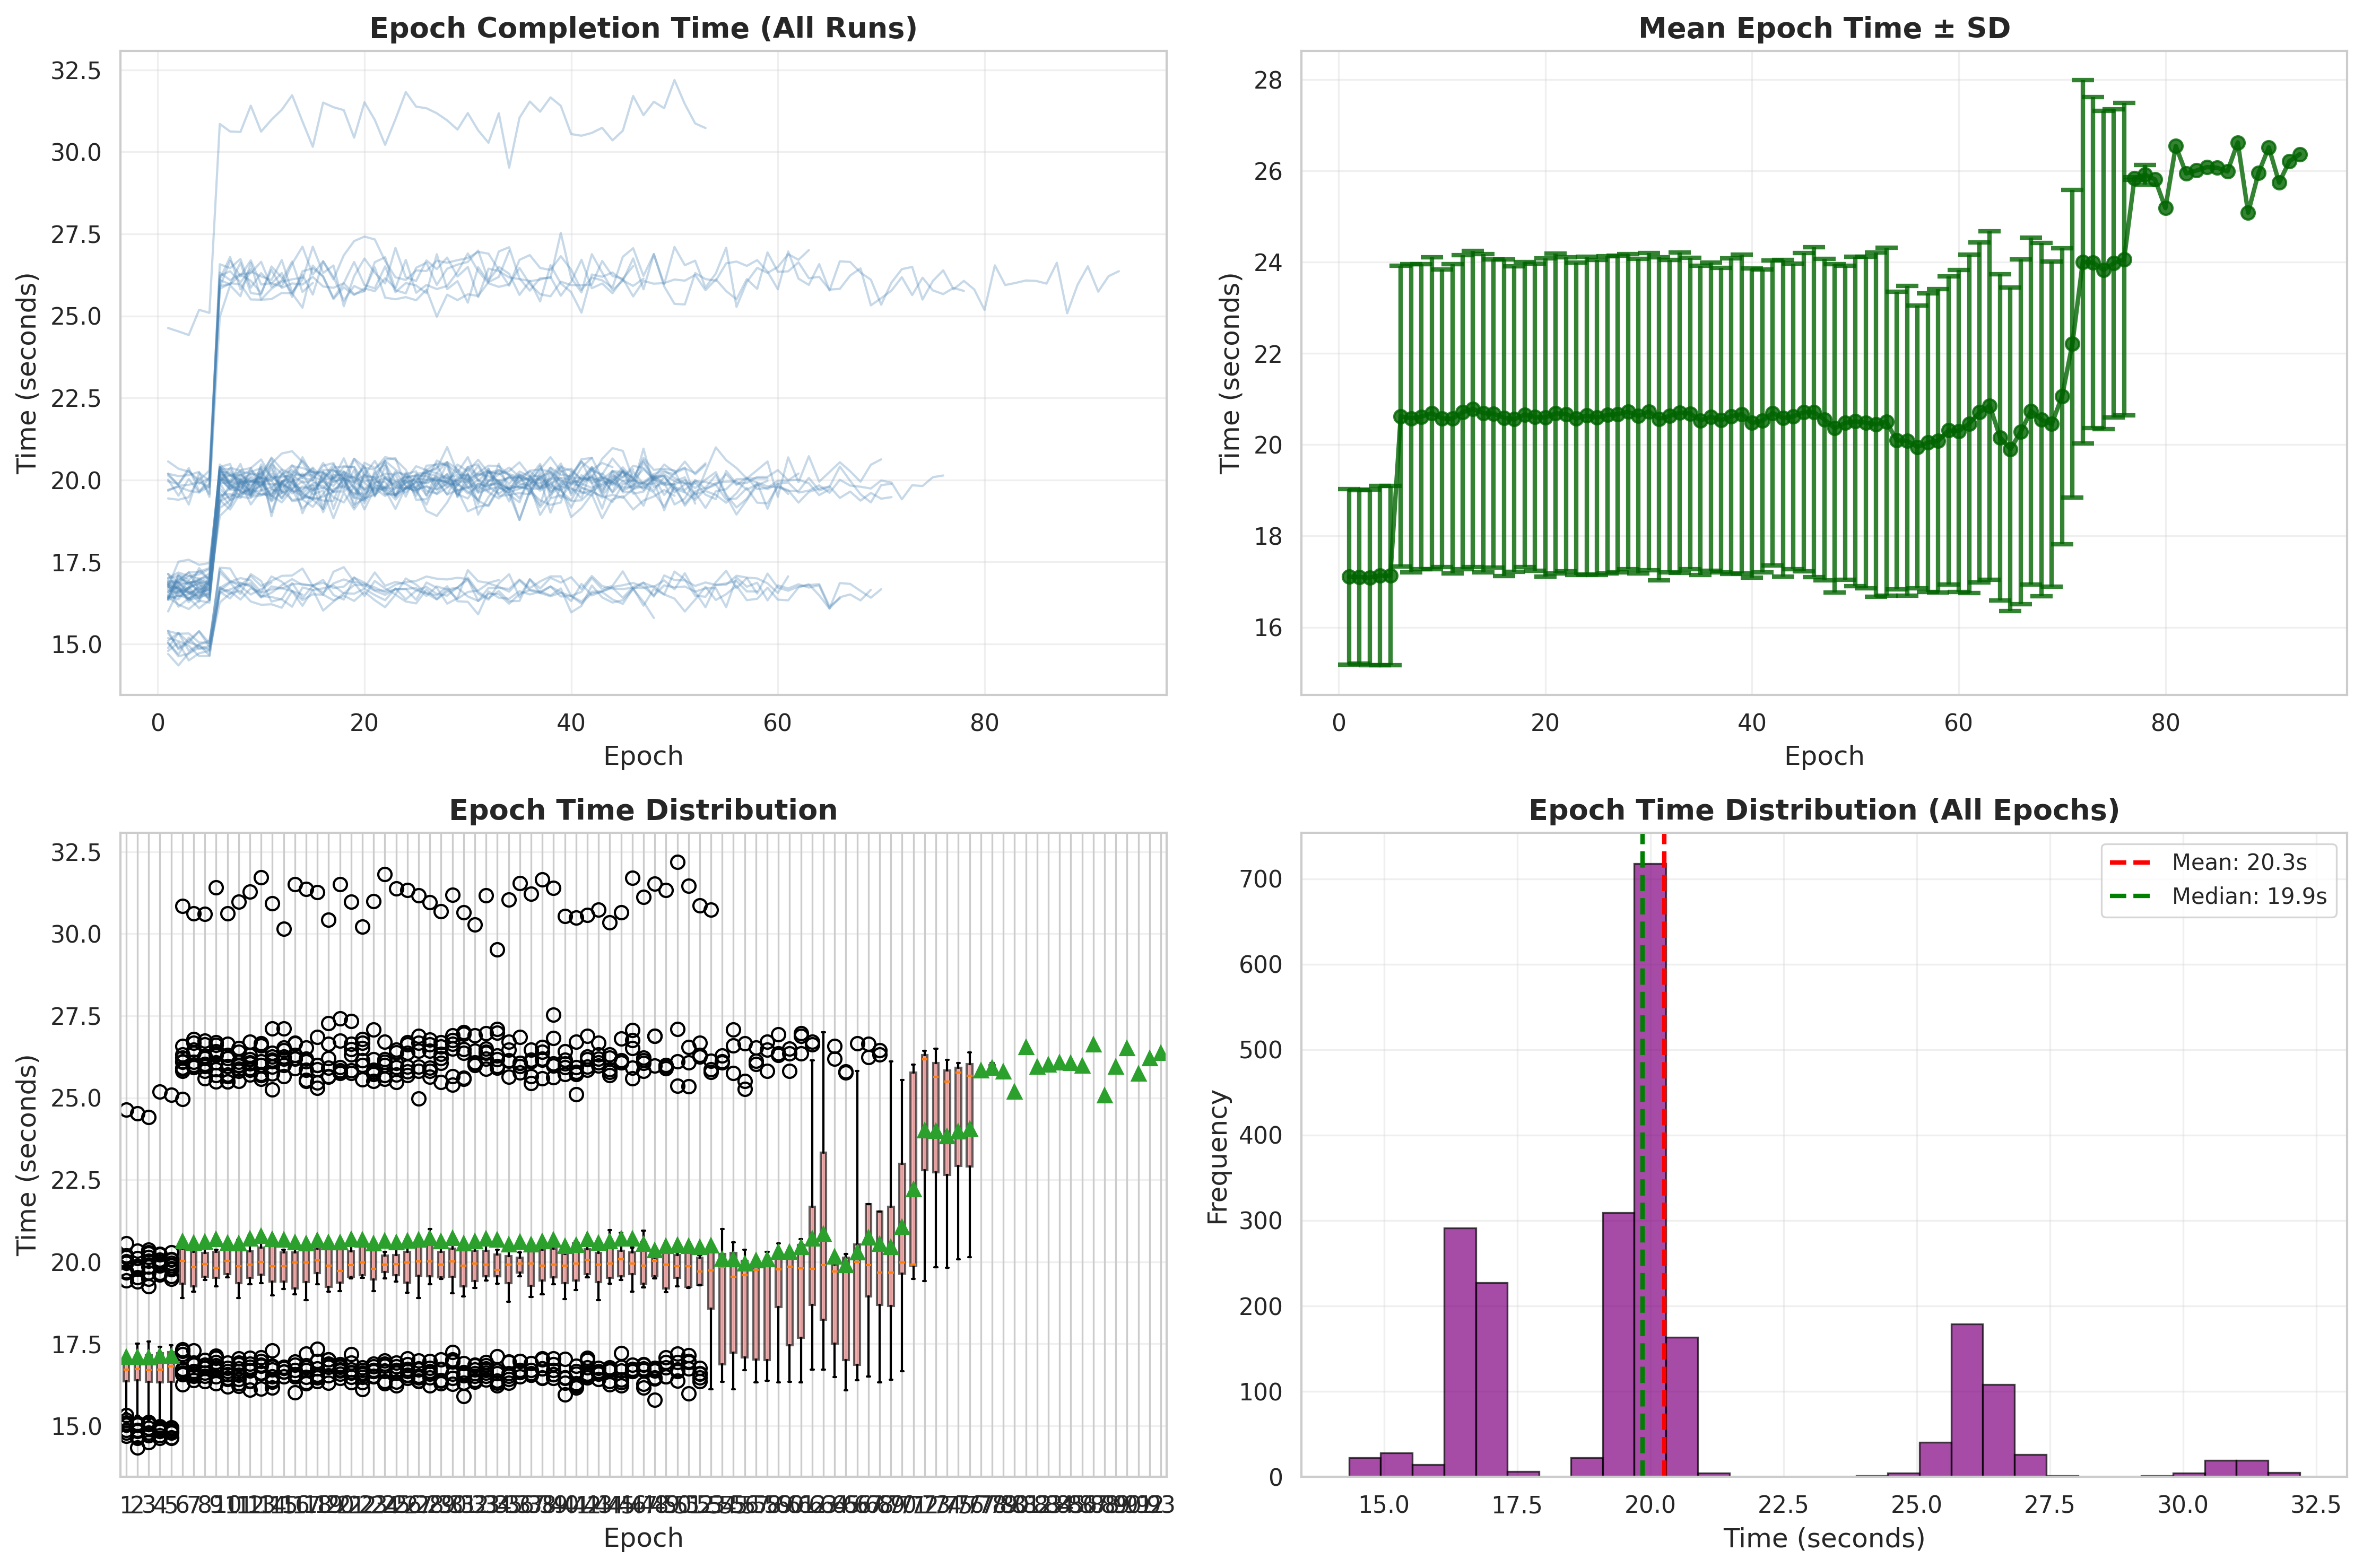

✓ Epoch timing visualization saved!


In [22]:
if epoch_times_all and 'epoch' in epoch_df.columns and 'epoch_time' in epoch_df.columns:
    # Visualize epoch completion times
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Individual epoch times (all runs)
    for (fold, run), group in epoch_df.groupby(['fold', 'run']):
        group_clean = group.dropna(subset=['epoch', 'epoch_time']).sort_values('epoch')
        if len(group_clean) > 0:
            axes[0,0].plot(group_clean['epoch'], group_clean['epoch_time'], 
                         alpha=0.3, lw=1, color='steelblue')
    
    axes[0,0].set_xlabel('Epoch', fontsize=12)
    axes[0,0].set_ylabel('Time (seconds)', fontsize=12)
    axes[0,0].set_title('Epoch Completion Time (All Runs)', fontsize=13, fontweight='bold')
    axes[0,0].grid(alpha=0.3)
    
    # Plot 2: Mean epoch time with error bars
    per_epoch_mean = epoch_df.groupby('epoch')['epoch_time'].mean()
    per_epoch_std = epoch_df.groupby('epoch')['epoch_time'].std()
    epochs = per_epoch_mean.index
    
    axes[0,1].errorbar(epochs, per_epoch_mean, yerr=per_epoch_std, 
                      fmt='o-', capsize=5, capthick=2, markersize=6, 
                      color='darkgreen', alpha=0.8, linewidth=2)
    axes[0,1].set_xlabel('Epoch', fontsize=12)
    axes[0,1].set_ylabel('Time (seconds)', fontsize=12)
    axes[0,1].set_title('Mean Epoch Time ± SD', fontsize=13, fontweight='bold')
    axes[0,1].grid(alpha=0.3)
    
    # Plot 3: Box plot per epoch
    epoch_data = [epoch_df[epoch_df['epoch'] == e]['epoch_time'].dropna().values 
                  for e in sorted(epoch_df['epoch'].unique())]
    epoch_labels = [str(int(e)) for e in sorted(epoch_df['epoch'].unique())]
    
    bp = axes[1,0].boxplot(epoch_data, labels=epoch_labels, patch_artist=True, showmeans=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.6)
    
    axes[1,0].set_xlabel('Epoch', fontsize=12)
    axes[1,0].set_ylabel('Time (seconds)', fontsize=12)
    axes[1,0].set_title('Epoch Time Distribution', fontsize=13, fontweight='bold')
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # Plot 4: Histogram of all epoch times
    axes[1,1].hist(epoch_df['epoch_time'].dropna(), bins=30, 
                  color='purple', alpha=0.7, edgecolor='black')
    axes[1,1].axvline(epoch_df['epoch_time'].mean(), color='red', 
                     linestyle='--', linewidth=2, label=f"Mean: {epoch_df['epoch_time'].mean():.1f}s")
    axes[1,1].axvline(epoch_df['epoch_time'].median(), color='green', 
                     linestyle='--', linewidth=2, label=f"Median: {epoch_df['epoch_time'].median():.1f}s")
    axes[1,1].set_xlabel('Time (seconds)', fontsize=12)
    axes[1,1].set_ylabel('Frequency', fontsize=12)
    axes[1,1].set_title('Epoch Time Distribution (All Epochs)', fontsize=13, fontweight='bold')
    axes[1,1].legend(fontsize=10)
    axes[1,1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'figures/epoch_timing_analysis.png'), 
               dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Epoch timing visualization saved!")

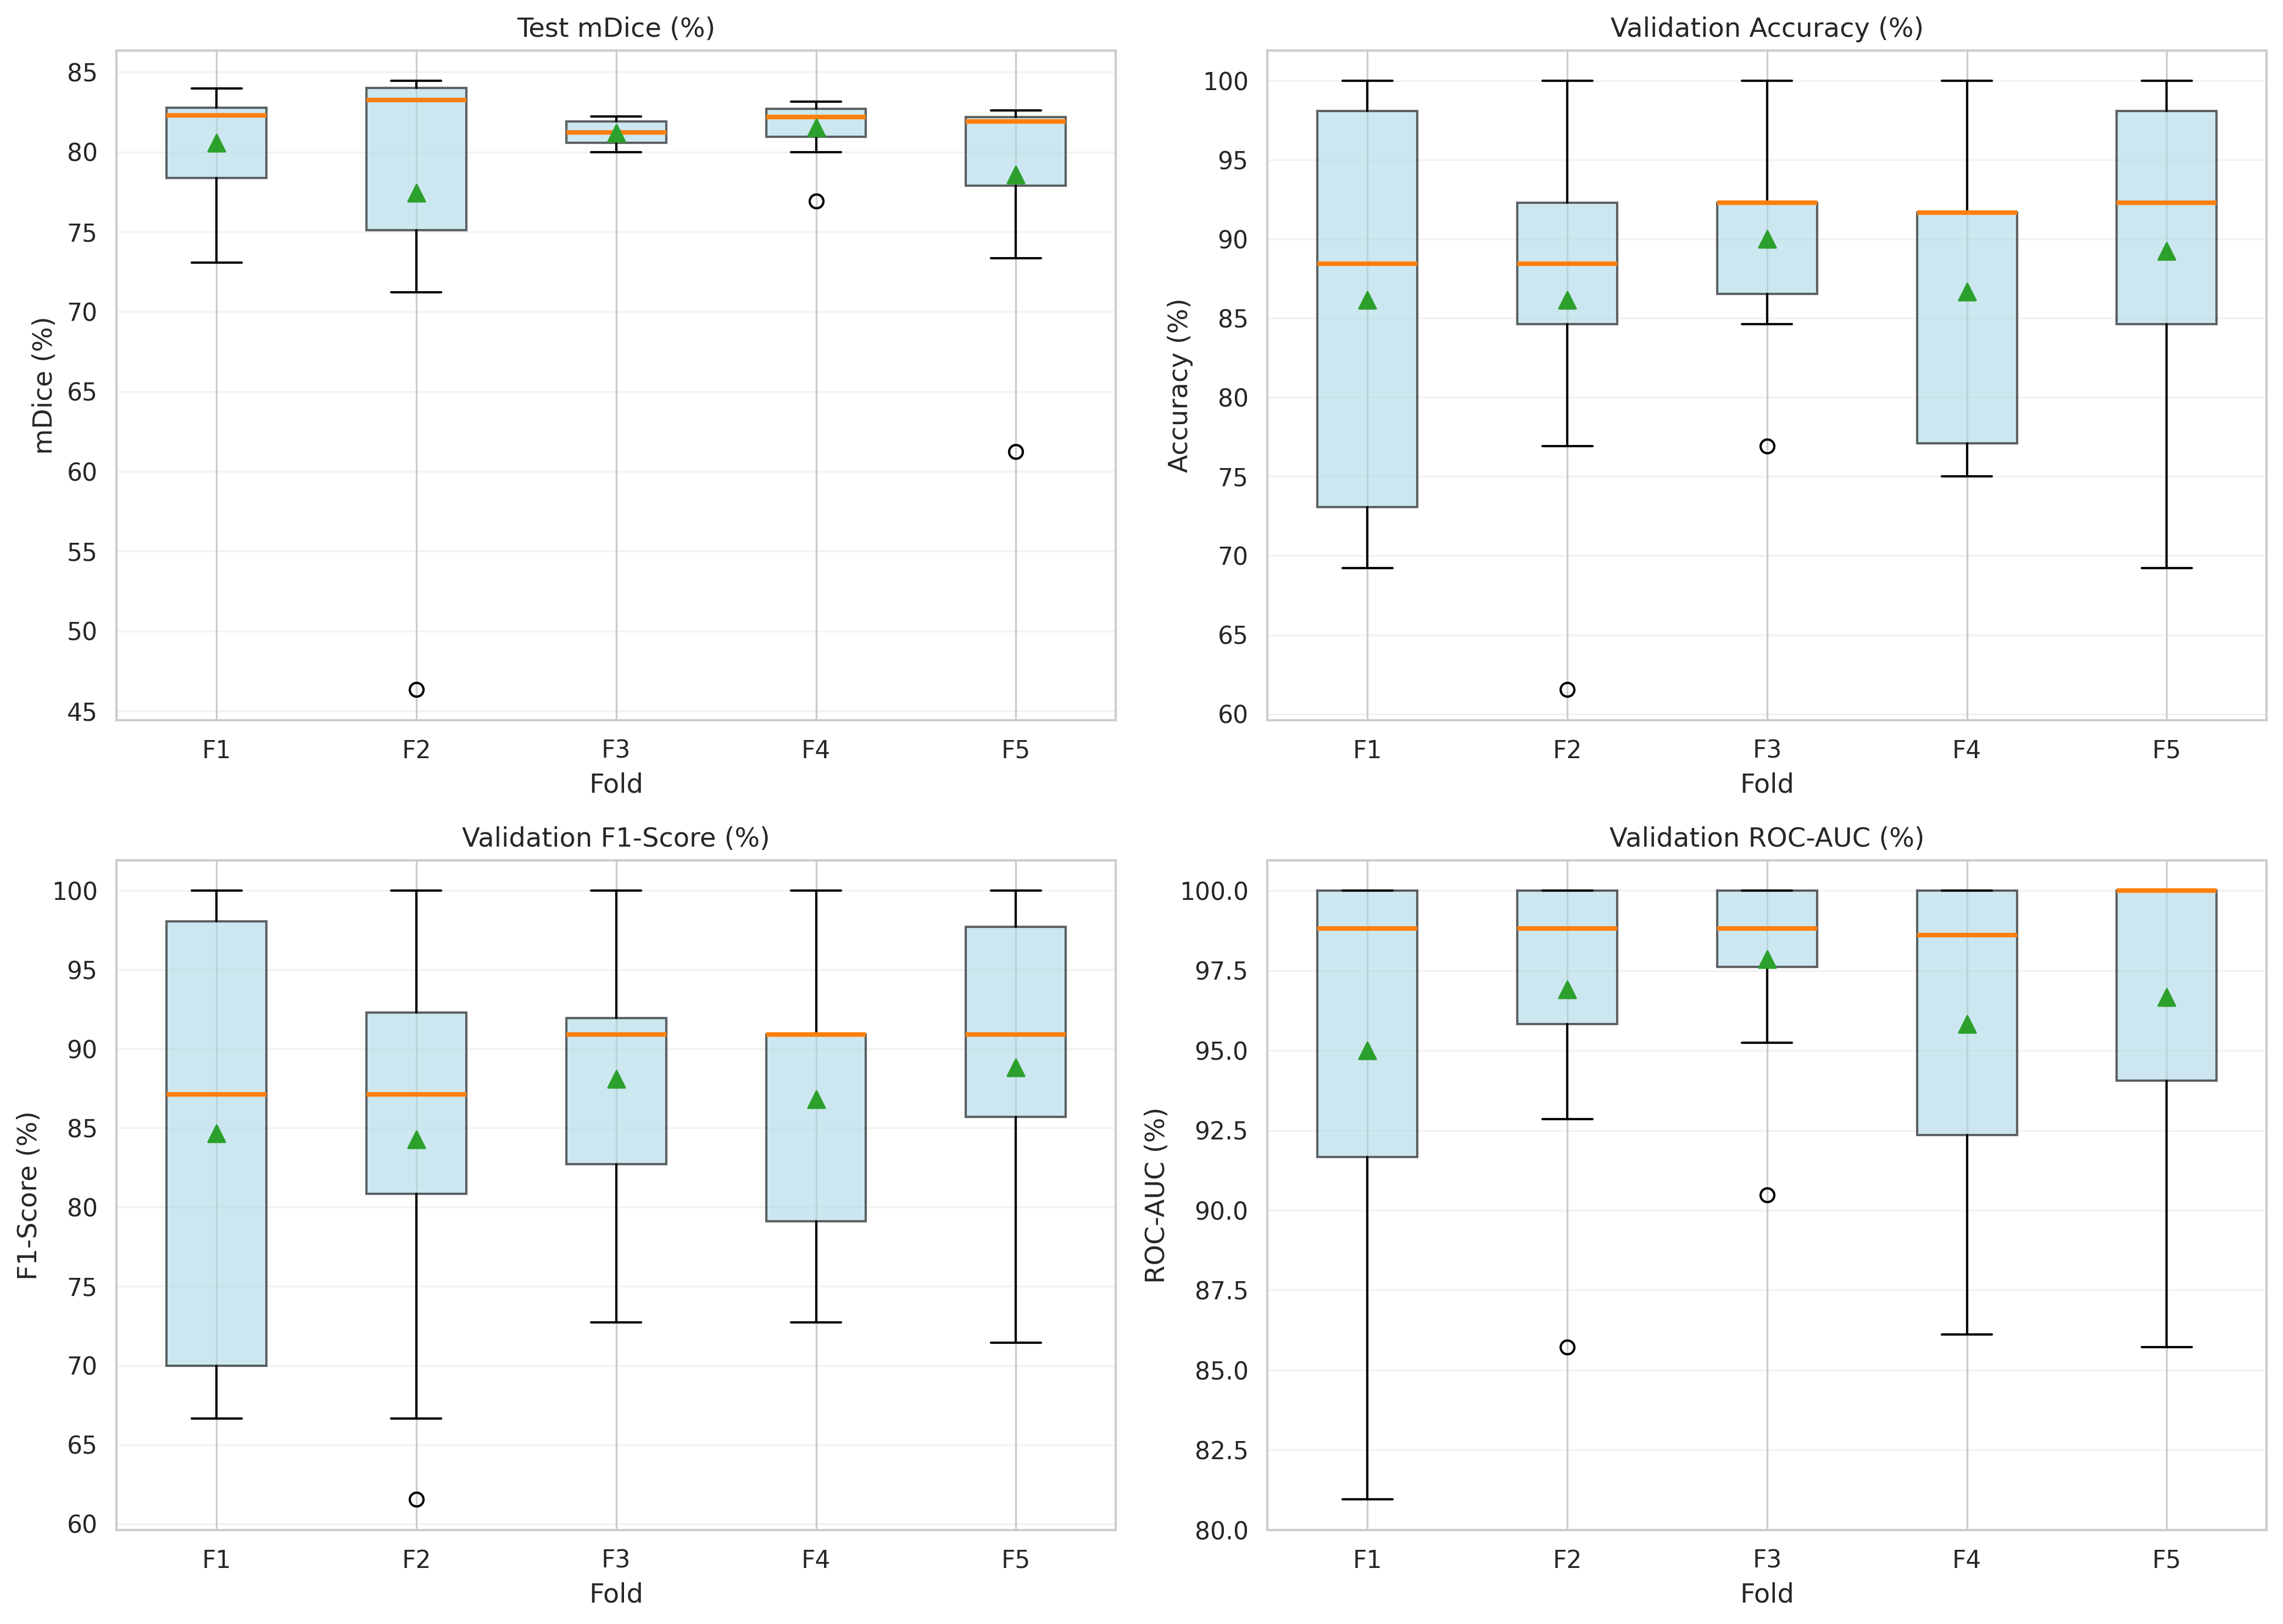

Kaydedildi: q1_publication_results/figures/per_fold_boxplots_fixed.png


,metric,column,label
0,mDice,final_test_mDice_fg_patient,Test mDice (%)
1,Accuracy,final_val_cls_acc_patient,Validation Accuracy (%)
2,F1-Score,final_val_cls_f1_patient,Validation F1-Score (%)
3,ROC-AUC,final_val_cls_roc_auc_patient,Validation ROC-AUC (%)


Not: Summary tabloda final_test_cls_* kolonlari yok; classification panelleri validation metrikleriyle cizildi.


In [24]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path(FIG_DIR) if "FIG_DIR" in globals() else Path("q1_publication_results")
OUTPUT_BASE = Path(OUTPUT_BASE) if "OUTPUT_BASE" in globals() else Path("folds/folds/output")

def _styled_boxplot(ax, data_by_fold, title, ylabel, fold_labels):
    bp = ax.boxplot(data_by_fold, tick_labels=fold_labels, patch_artist=True, showfliers=True, widths=0.5)
    for patch in bp["boxes"]:
        patch.set_facecolor("#add8e6")
        patch.set_alpha(0.6)
        patch.set_edgecolor("black")
    for med in bp["medians"]:
        med.set_color("#ff7f0e")
        med.set_linewidth(2)
    for item in bp["whiskers"] + bp["caps"]:
        item.set_color("black")
    means = [float(np.mean(x)) if len(x) else np.nan for x in data_by_fold]
    ax.scatter(np.arange(1, len(means) + 1), means, marker="^", s=55, color="#2ca02c", zorder=3)
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)

metric_files = sorted(OUTPUT_BASE.glob("FOLD_*/run_*/final/final_fold_test_metrics.json"))
if not metric_files:
    raise FileNotFoundError(f"No final_fold_test_metrics.json files found under {OUTPUT_BASE}")

rows = []
for path in metric_files:
    payload = pd.read_json(path, typ="series")
    rows.append({
        "fold": path.parts[-4],
        "run_idx": path.parts[-3],
        "test_mDice_fg_patient": payload.get("eval_mDice_fg_patient", np.nan),
        "test_cls_acc_patient": payload.get("eval_cls_acc_patient", np.nan),
        "test_cls_f1_patient": payload.get("eval_cls_f1_patient", np.nan),
        "test_cls_roc_auc_patient": payload.get("eval_cls_roc_auc_patient", np.nan),
        "test_cls_pr_auc_patient": payload.get("eval_cls_pr_auc_patient", np.nan),
    })

test_metrics_df = pd.DataFrame(rows).sort_values(["fold", "run_idx"]).reset_index(drop=True)
metric_specs = [
    ("test_mDice_fg_patient", "Test mDice (%)", "mDice (%)"),
    ("test_cls_acc_patient", "Test Accuracy (%)", "Accuracy (%)"),
    ("test_cls_f1_patient", "Test F1-Score (%)", "F1-Score (%)"),
    ("test_cls_roc_auc_patient", "Test ROC-AUC (%)", "ROC-AUC (%)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flatten()

for ax, (col, title, ylabel) in zip(axes_flat, metric_specs):
    data = []
    labels = []
    for fold in sorted(test_metrics_df["fold"].unique()):
        fold_values = pd.to_numeric(test_metrics_df.loc[test_metrics_df["fold"] == fold, col], errors="coerce").dropna().to_numpy(dtype=float) * 100.0
        if fold_values.size == 0:
            continue
        data.append(fold_values)
        labels.append(str(fold).replace("FOLD_", "F"))
    _styled_boxplot(ax, data, title, ylabel, labels)

for ax in axes_flat[len(metric_specs):]:
    ax.axis("off")

plt.tight_layout()
out_png = FIG_DIR / "figures/per_fold_boxplots_fixed.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("Kaydedildi:", out_png)

source_csv = FIG_DIR / "tables/per_fold_test_metrics_by_run.csv"
test_metrics_df.to_csv(source_csv, index=False)
print("Kaydedildi:", source_csv)
display(test_metrics_df.head())
